# PYTHON ANALYSIS : the effect of a prevention program on wrist extension and forearm supination in leather workers.
_Student : DUPLAIX JAHINNA_

This notebook contains the Python part of the movement analysis project.

It is organized into two main parts:

__Part 1 — Data cleaning and preparation__
- read and inspect the raw dataset
- clean and validate the data
- check the longitudinal structure
- create the final complete-case analysis dataset

__Part 2 — Outcome computation and exploratory analysis__
- create the primary outcome variables
- inspect extreme change scores
- produce descriptive and exploratory outputs
- export the final dataset for the statistical analyses in RStudio

______________
# PART I : DATA CLEANING AND PREPARATION

In [129]:
# Import the library used to manage file paths in a clean and portable way
from pathlib import Path

# Import pandas to read, clean, and manipulate tabular data
import pandas as pd

# Import matplotlib to create simple figures in Python
import matplotlib.pyplot as plt

# Import display from IPython to display dataframes and figures in the notebook in a clean way
from IPython.display import display

# Import numpy to perform numerical operations on arrays
import numpy as np

## 1. Define project paths

Project folders are defined at the beginning of the notebook so that file paths remain clear, consistent, and portable.

In [130]:
# Define the main project folders
data_dir = Path("data")
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"
results_dir = Path("results")
figures_dir = results_dir / "figures_exploratory"
tables_dir = results_dir / "tables_exploratory"

# Define the input Excel file
input_file = raw_dir / "TMinstitute_prevention_base_2025.xlsx"

# Make sure the output folders exist
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

# Print the main paths to check that they are correct
print("Raw data folder:", raw_dir)
print("Processed folder:", processed_dir)
print("Results folder:", results_dir)
print("Figures folder:", figures_dir)
print("Tables folder:", tables_dir)
print("Input file:", input_file)

Raw data folder: data\raw
Processed folder: data\processed
Results folder: results
Figures folder: results\figures_exploratory
Tables folder: results\tables_exploratory
Input file: data\raw\TMinstitute_prevention_base_2025.xlsx


## 2. Read the raw dataset

The Excel file is opened and the relevant worksheet is identified.

The movement data are then loaded into a raw dataframe, which is kept unchanged throughout the cleaning process.

In [131]:
# Open the Excel file
excel_file = pd.ExcelFile(input_file)

# Display the names of all sheets in the Excel file
print("Available sheets:", excel_file.sheet_names)

# Read the sheet containing the movement data
df_raw = pd.read_excel(input_file, sheet_name="range_of_motion")

# Display the first rows of the raw dataset
display(df_raw.head())

Available sheets: ['range_of_motion']


,participant_id,timepoint,wrist_extension_deg,forearm_supination_deg
0,M001,T0,51.9,82.1
1,M001,T1,55.3,85.4
2,M002,T0,43.2,70.5
3,M002,T1,44.7,74.2
4,M003,T0,47.2,62.6


### _First file inspection_
The Excel file was successfully opened and the relevant worksheet was identified.

The first rows of the raw dataset confirm that the expected variables are present.

## 3. Inspect the raw dataset

The raw dataset is inspected before any cleaning step.

The purpose of this section is to:
- check the size of the dataset
- confirm the variable names
- inspect the variable types
- inspect the timepoint labels
- detect missing values
- detect exact duplicated rows

In [132]:
# Display the number of rows and columns
print("Shape:", df_raw.shape)

# Display the names of all columns
print("Columns:", df_raw.columns.tolist())

# Display the data type of each column
print(df_raw.dtypes)

# Display the values present in the timepoint column
print(df_raw["timepoint"].value_counts(dropna=False))

# Count missing values in the two movement variables
print(df_raw[["wrist_extension_deg", "forearm_supination_deg"]].isna().sum())

# Count missing values in the key structural variables
print(df_raw[["participant_id", "timepoint"]].isna().sum())

# Count exact duplicate rows
print("Number of exact duplicate rows:", df_raw.duplicated().sum())

Shape: (950, 4)
Columns: ['participant_id', 'timepoint', 'wrist_extension_deg', 'forearm_supination_deg']
participant_id                str
timepoint                     str
wrist_extension_deg       float64
forearm_supination_deg     object
dtype: object
timepoint
T0     475
T1     470
T0       1
t0       1
T 1      1
t1       1
T 0      1
Name: count, dtype: int64
wrist_extension_deg       4
forearm_supination_deg    4
dtype: int64
participant_id    0
timepoint         0
dtype: int64
Number of exact duplicate rows: 4


### _Initial observations_
Our dataset contains a single Excel sheet "range_of_motion" with 950 rows and 4 columns. So we have 4 variables:

- participant_id
- timepoint
- wrist_extension_deg
- forearm_supination_deg

The first inspection also shows that:

- some timepoint labels are not fully harmonized
- forearm supination is not yet stored as a numeric variable
- a few missing values are present
- a few exact duplicate rows are present

These observations guide the cleaning steps in the next section.
The next step is to clean the dataset.

## 4. Clean the dataset

The raw dataset is now cleaned in order to prepare a valid longitudinal dataset.

The cleaning steps include:
- standardizing participant identifiers
- harmonizing timepoint labels
- converting movement variables to numeric format
- identifying implausible raw movement values
- removing exact duplicated rows

The remaining missing values are not removed at this stage.

They will be handled later when creating the final complete-case analysis dataset.

In [133]:
# Create a working copy of the raw dataset : The raw dataset remains unchanged and is kept for reference
df = df_raw.copy()

# Standardize participant identifiers : Convert to string and remove leading and trailing spaces
df["participant_id"] = df["participant_id"].astype(str).str.strip()

# Standardize timepoint labels : Convert to string first
df["timepoint"] = df["timepoint"].astype(str)

# Remove leading and trailing spaces
df["timepoint"] = df["timepoint"].str.strip()

# Remove standard spaces inside the label (e.g., "T 0" becomes "T0")
df["timepoint"] = df["timepoint"].str.replace(" ", "", regex=False)

# Remove non-breaking spaces if they exist
df["timepoint"] = df["timepoint"].str.replace("\u00A0", "", regex=False)

# Convert labels to uppercase (e.g., "t0" becomes "T0")
df["timepoint"] = df["timepoint"].str.upper()

# Replace known inconsistent variants
df["timepoint"] = df["timepoint"].replace({
    "TØ": "T0"
})

# Convert forearm supination to numeric values : first convert to string so that text cleaning can be applied
df["forearm_supination_deg"] = df["forearm_supination_deg"].astype(str)

# Remove the degree symbol if it exists
df["forearm_supination_deg"] = df["forearm_supination_deg"].str.replace("°", "", regex=False)

# Remove leading and trailing spaces
df["forearm_supination_deg"] = df["forearm_supination_deg"].str.strip()

# Convert the cleaned values to numeric format : non-convertible values become missing values (NaN)
df["forearm_supination_deg"] = pd.to_numeric(df["forearm_supination_deg"], errors="coerce")

# Identify implausible raw wrist extension values : here, values above 180 degrees are considered impossible for this variable
implausible_ext = df["wrist_extension_deg"] > 180

# Display rows with implausible raw wrist extension values
print("Rows with implausible raw wrist extension values:")
display(df.loc[implausible_ext, ["participant_id", "timepoint", "wrist_extension_deg", "forearm_supination_deg"]])

# Recode implausible wrist extension values as missing
df.loc[implausible_ext, "wrist_extension_deg"] = pd.NA

# Remove exact duplicated rows
df = df.drop_duplicates()

print("Data cleaning completed. Here are the checks after cleaning:")
# Check the cleaned timepoint labels
print("Timepoint values after cleaning:")
print(df["timepoint"].value_counts(dropna=False))

# Check the data types after cleaning
print("\nDtypes after cleaning:")
print(df.dtypes)

# Check missing values after cleaning
print("\nMissing values in movement variables:")
print(df[["wrist_extension_deg", "forearm_supination_deg"]].isna().sum())
print("\nMissing values in structural variables:")
print(df[["participant_id", "timepoint"]].isna().sum())

# Check the number of rows after removing exact duplicates
print("Shape after cleaning:", df.shape)

# Check that no exact duplicate rows remain
print("Number of exact duplicate rows after cleaning:", df.duplicated().sum())

Rows with implausible raw wrist extension values:


,participant_id,timepoint,wrist_extension_deg,forearm_supination_deg
318,M160,T0,462.0,75.7


Data cleaning completed. Here are the checks after cleaning:
Timepoint values after cleaning:
timepoint
T0    474
T1    472
Name: count, dtype: int64

Dtypes after cleaning:
participant_id                str
timepoint                     str
wrist_extension_deg       float64
forearm_supination_deg    float64
dtype: object

Missing values in movement variables:
wrist_extension_deg       5
forearm_supination_deg    4
dtype: int64

Missing values in structural variables:
participant_id    0
timepoint         0
dtype: int64
Shape after cleaning: (946, 4)
Number of exact duplicate rows after cleaning: 0


### _First cleaning summary_

After cleaning:

- participant identifiers are standardized
- timepoint labels are harmonized into T0 and T1
- forearm_supination_deg is stored as a numeric variable
- one implausible raw wrist extension value was identified and recoded as missing
- exact duplicate rows have been removed

The cleaned long-format dataset now contains 946 rows.

At this stage:

- no missing values remain in participant_id or timepoint
- 5 missing values remain in wrist_extension_deg
- 4 missing values remain in forearm_supination_deg

The remaining incomplete rows will be inspected in the next section.

## 5. Inspect incomplete rows

After our first clean, a small number of missing values remain in the movement variables.

These incomplete rows are displayed in order to identify:

- which participants are concerned
- which timepoints are incomplete
- which movement variables are missing

At this stage, the rows are not removed yet.
They will be handled later when creating the final complete-case analysis dataset.

In [134]:
# Display rows with at least one missing movement value
missing_rows = df[
    df["wrist_extension_deg"].isna() | df["forearm_supination_deg"].isna()
]
# Display the number of incomplete rows
print("Number of incomplete rows:", len(missing_rows))

print(missing_rows)

Number of incomplete rows: 9
    participant_id timepoint  wrist_extension_deg  forearm_supination_deg
165           M083        T1                  NaN                    70.6
307           M154        T1                 63.4                     NaN
315           M158        T1                  NaN                    74.6
318           M160        T0                  NaN                    75.7
394           M198        T0                 40.8                     NaN
452           M227        T0                  NaN                    76.2
602           M302        T0                  NaN                    67.4
694           M348        T0                 66.6                     NaN
894           M448        T0                 46.9                     NaN


### _Observation on incomplete rows_

The cleaned long-format dataset still contains a small number of incomplete observations.

A total of 9 participant-timepoint rows contain at least one missing value in the movement variables.

These incomplete rows involve:

- 5 missing values in wrist_extension_deg
- 4 missing values in forearm_supination_deg

The rows are not removed at this stage because the dataset is still stored in long format.
Missing movement values will be handled later when creating the final complete-case analysis dataset after reshaping the data into wide format.

## 6. Check the longitudinal structure

Before reshaping the dataset into wide format, the participant structure must be checked.

This step verifies that:

- participant identifiers follow the expected format
- each participant has exactly two rows
- each participant has two distinct timepoints
- no duplicated participant-timepoint combinations remain

This ensures that the longitudinal structure is valid before computing within-participant changes between T0 and T1.

In [135]:
# Check whether participant IDs follow the expected format: M followed by 3 digits
invalid_ids = df.loc[~df["participant_id"].str.fullmatch(r"M\d{3}"), "participant_id"].unique()
print("Participant IDs with unexpected format:")
print(invalid_ids)

# Count the number of rows per participant
rows_per_participant = df.groupby("participant_id").size()
print("Distribution of rows per participant:")
print(rows_per_participant.value_counts().sort_index())

# Display participants who do not have exactly 2 rows
problem_rows = rows_per_participant[rows_per_participant != 2]
print("Participants with a number of rows different from 2:")
print(problem_rows)

# Count the number of distinct timepoints per participant
timepoints_per_participant = df.groupby("participant_id")["timepoint"].nunique()
print("Distribution of distinct timepoints per participant:")
print(timepoints_per_participant.value_counts().sort_index())

# Display participants who do not have exactly 2 distinct timepoints
problem_timepoints = timepoints_per_participant[timepoints_per_participant != 2]
print("Participants with a number of distinct timepoints different from 2:")
print(problem_timepoints)

# Check duplicated participant-timepoint combinations
duplicate_pairs = df.duplicated(subset=["participant_id", "timepoint"]).sum()
print("Duplicated participant-timepoint pairs:", duplicate_pairs)



Participant IDs with unexpected format:
<StringArray>
[]
Length: 0, dtype: str
Distribution of rows per participant:
2    473
Name: count, dtype: int64
Participants with a number of rows different from 2:
Series([], dtype: int64)
Distribution of distinct timepoints per participant:
timepoint
1      3
2    470
Name: count, dtype: int64
Participants with a number of distinct timepoints different from 2:
participant_id
M148    1
M212    1
M285    1
Name: timepoint, dtype: int64
Duplicated participant-timepoint pairs: 3


### _Longitudinal structure summary_

The participant identifiers follow the expected format.
All participants have exactly two rows in the cleaned long-format dataset.

However, 3 participants have only one distinct timepoint:
- M148
- M212
- M285

These cases correspond to duplicated participant-timepoint combinations and do not allow a valid within-participant change between T0 and T1 to be computed.

They must therefore be excluded before reshaping the dataset into wide format.

## 7. Inspect and exclude invalid participants

The previous step showed that 3 participants have two rows but only one distinct timepoint.

These participants are inspected and then excluded because a valid within-participant change between T0 and T1 cannot be computed for them.

In [136]:
# Extract the IDs of participants with an invalid longitudinal structure
invalid_participants = problem_timepoints.index.tolist()

# Display the invalid participant IDs
print("Invalid participants:")
print(invalid_participants)

# Display the rows corresponding to these invalid participants
invalid_rows = df[df["participant_id"].isin(invalid_participants)].sort_values(
["participant_id", "timepoint"]
)

print(invalid_rows)

Invalid participants:
['M148', 'M212', 'M285']
    participant_id timepoint  wrist_extension_deg  forearm_supination_deg
294           M148        T0                 50.3                    56.9
295           M148        T0                 50.4                    55.8
422           M212        T1                 53.1                    64.5
423           M212        T1                 56.0                    65.6
568           M285        T0                 52.9                    72.5
569           M285        T0                 52.8                    72.8


### _Observation on invalid participants_

The 3 invalid participants were reviewed directly in the cleaned long-format dataset:
- M148
- M212
- M285

Each of them has two rows but only one distinct timepoint:

- M148 has T0 twice
- M212 has T1 twice
- M285 has T0 twice

Because a valid paired change between T0 and T1 cannot be computed for these participants, they must be excluded before reshaping the dataset into wide format.

In [137]:
# Remove participants with an invalid longitudinal structure
df_valid = df[~df["participant_id"].isin(invalid_participants)].copy()

# Display the number of rows remaining in the valid long-format dataset
print("Rows in the valid long-format dataset:", len(df_valid))

# Display the number of participants remaining
print("Participants in the valid long-format dataset:", df_valid["participant_id"].nunique())

Rows in the valid long-format dataset: 940
Participants in the valid long-format dataset: 470


### _Valid long-format dataset_

After excluding participants with an invalid longitudinal structure, the valid long-format dataset contains:
- 940 rows
- 470 participants

This valid long-format dataset is now ready to be reshaped into wide format.

## 8. Reshape the valid dataset into wide format

The valid long-format dataset is now converted into wide format.

In the wide-format dataset, each participant has one row containing:

- wrist extension at T0
- wrist extension at T1
- forearm supination at T0
- forearm supination at T1

This format is required for the computation of within-participant changes.

In [138]:
# Convert the valid long-format dataset to wide format : each participant will have one row, the values at T0 and T1 will become separate columns
df_wide = df_valid.pivot(
    index="participant_id",
    columns="timepoint",
    values=["wrist_extension_deg", "forearm_supination_deg"]
)

# Flatten the multi-level column names, (e.g., ("wrist_extension_deg", "T0") becomes "wrist_extension_deg_T0")
df_wide.columns = [f"{var}_{tp}" for var, tp in df_wide.columns]

# Turn participant_id back into a standard column
df_wide = df_wide.reset_index()

# Display the size of the wide dataset
print("Shape of wide dataset:", df_wide.shape)

# Display the first rows of the wide dataset
display(df_wide.head())

# Display the data types in the wide dataset
print(df_wide.dtypes)

Shape of wide dataset: (470, 5)


,participant_id,wrist_extension_deg_T0,wrist_extension_deg_T1,forearm_supination_deg_T0,forearm_supination_deg_T1
0,M001,51.9,55.3,82.1,85.4
1,M002,43.2,44.7,70.5,74.2
2,M003,47.2,47.8,62.6,64.3
3,M004,46.0,45.1,72.9,74.4
4,M005,56.4,59.1,65.2,69.1


participant_id                   str
wrist_extension_deg_T0       float64
wrist_extension_deg_T1       float64
forearm_supination_deg_T0    float64
forearm_supination_deg_T1    float64
dtype: object


### _Wide-format dataset summary_

The valid long-format dataset was successfully reshaped into wide format.

The wide-format dataset contains:

- 470 participants
- one row per participant
- paired movement variables at T0 and T1

The movement variables are stored in numeric format, which makes this dataset suitable for missing value checks and for the computation of within-participant changes.

## 9. Check missing values in the wide dataset

Missing values are checked again after reshaping the valid dataset into wide format.

This step identifies which participants still have incomplete movement data and prepares the creation of the final complete-case analysis dataset.

In [139]:
# Count missing values in each column of the wide dataset
print(df_wide.isna().sum())

# Display the number of rows in the wide dataset
print("Rows in wide dataset:", len(df_wide))

participant_id               0
wrist_extension_deg_T0       3
wrist_extension_deg_T1       2
forearm_supination_deg_T0    3
forearm_supination_deg_T1    1
dtype: int64
Rows in wide dataset: 470


### _Missing values in the wide dataset_

The wide-format dataset contains 470 participants.

Some movement variables still contain missing values:

- 3 in wrist_extension_deg_T0
- 2 in wrist_extension_deg_T1
- 3 in forearm_supination_deg_T0
- 1 in forearm_supination_deg_T1

These incomplete observations prevent the computation of complete paired changes for some participants.

A final complete-case analysis dataset will therefore be created in the next step.

## 10. Create the final analysis dataset

The statistical analyses require complete values for both movement variables at both timepoints.

A final complete-case analysis dataset is therefore created by keeping only participants with complete data for:

- wrist extension at T0 and T1
- forearm supination at T0 and T1

In [140]:
# Keep only participants with complete data on all four movement variables
analysis_df = df_wide.dropna(
    subset=[
        "wrist_extension_deg_T0",
        "wrist_extension_deg_T1",
        "forearm_supination_deg_T0",
        "forearm_supination_deg_T1"
    ]
).copy()

# Display the number of rows in the final analysis dataset
print("Rows in final analysis dataset:", len(analysis_df))

# Display the number of excluded participants
print("Participants excluded because of missing movement data:", len(df_wide) - len(analysis_df))

# Display the shape of the final analysis dataset
print("Final shape of analysis_df:", analysis_df.shape)

# Display the first rows of the final analysis dataset
display(analysis_df.head())

Rows in final analysis dataset: 461
Participants excluded because of missing movement data: 9
Final shape of analysis_df: (461, 5)


,participant_id,wrist_extension_deg_T0,wrist_extension_deg_T1,forearm_supination_deg_T0,forearm_supination_deg_T1
0,M001,51.9,55.3,82.1,85.4
1,M002,43.2,44.7,70.5,74.2
2,M003,47.2,47.8,62.6,64.3
3,M004,46.0,45.1,72.9,74.4
4,M005,56.4,59.1,65.2,69.1


### _Final analysis dataset_

The final complete-case analysis dataset contains 461 participants.

In total:

- 3 participants were excluded because of an invalid longitudinal structure
- 9 participants were excluded because of incomplete movement data

The final analysis dataset contains complete values for:
- wrist extension at T0 and T1
- forearm supination at T0 and T1

This dataset is now ready for the computation of the primary outcome variables.

## 11. Cleaning summary

The cleaning and preparation steps resulted in a valid complete-case dataset for the final analyses.

This section summarizes the main dataset sizes across the cleaning pipeline.

In [141]:
# Display a simple summary of the cleaning pipeline
print("Rows in raw imported dataset:", len(df_raw))
print("Rows after duplicate removal:", len(df))
print("Participants in cleaned long-format dataset:", df["participant_id"].nunique())
print("Participants excluded because of invalid longitudinal structure:", len(invalid_participants))
print("Participants remaining after structural check:", df_valid["participant_id"].nunique())
print("Participants excluded because of missing movement data:", len(df_wide) - len(analysis_df))
print("Final number of participants in analysis dataset:", analysis_df["participant_id"].nunique())

Rows in raw imported dataset: 950
Rows after duplicate removal: 946
Participants in cleaned long-format dataset: 473
Participants excluded because of invalid longitudinal structure: 3
Participants remaining after structural check: 470
Participants excluded because of missing movement data: 9
Final number of participants in analysis dataset: 461


### _Cleaning pipeline summary_

After standardization and duplicate removal, the cleaned long-format dataset contained `473 participants`.

Then:

- `3` participants were excluded because of an invalid longitudinal structure
- `9` participants were excluded because of incomplete movement data

The final complete-case analysis dataset contains `461 participants`.

The data cleaning and preparation phase is now complete.
The final analysis dataset is ready for the computation of the primary outcome variables.

________________
# PART 2 : OUTCOME COMPUTATION AND EXPLORATORY ANALYSIS

In this part, we create the change variables, export the final analysis dataset, and produce histograms to explore the distribution of the variables before the statistical analyses.

## 1. Create the primary outcome variables

The final complete-case analysis dataset is now used to compute the primary outcome variables.

Two change variables are created:

- `delta_wrist_extension_deg` = `wrist extension at T1` - `wrist extension at T0`
- `delta_forearm_supination_deg` = `forearm supination at T1` - `forearm supination at T0`

These variables represent the individual changes in range of motion and will be used in the subsequent descriptive and statistical analyses.

In [142]:
# Create the primary outcome variable for wrist extension
analysis_df["delta_wrist_extension_deg"] = (
    analysis_df["wrist_extension_deg_T1"] - analysis_df["wrist_extension_deg_T0"]
)

# Create the primary outcome variable for forearm supination
analysis_df["delta_forearm_supination_deg"] = (
    analysis_df["forearm_supination_deg_T1"] - analysis_df["forearm_supination_deg_T0"]
)

# Display the first rows of the updated analysis dataset
display(analysis_df.head())

# Display descriptive statistics for the two primary outcome variables
print("Descriptive statistics for delta_wrist_extension_deg and delta_forearm_supination_deg:")
display(analysis_df[["delta_wrist_extension_deg", "delta_forearm_supination_deg"]].describe())

,participant_id,wrist_extension_deg_T0,wrist_extension_deg_T1,forearm_supination_deg_T0,forearm_supination_deg_T1,delta_wrist_extension_deg,delta_forearm_supination_deg
0,M001,51.9,55.3,82.1,85.4,3.4,3.3
1,M002,43.2,44.7,70.5,74.2,1.5,3.7
2,M003,47.2,47.8,62.6,64.3,0.6,1.7
3,M004,46.0,45.1,72.9,74.4,-0.9,1.5
4,M005,56.4,59.1,65.2,69.1,2.7,3.9


Descriptive statistics for delta_wrist_extension_deg and delta_forearm_supination_deg:


,delta_wrist_extension_deg,delta_forearm_supination_deg
count,461.000000,461.000000
mean,1.657484,2.249024
std,2.645877,2.626699
min,-37.500000,-1.600000
25%,0.700000,0.900000
50%,1.700000,2.200000
75%,2.600000,3.300000
max,31.400000,35.500000


### _Summary of the primary outcome variables_

The two primary outcome variables were successfully computed:

- `delta_wrist_extension_deg`
- `delta_forearm_supination_deg`

The descriptive statistics show that most participants have small to moderate changes in range of motion between T0 and T1.

However, some extreme values are present in both delta variables.
These values must be inspected before the final dataset is exported and used for the statistical analyses in RStudio.

## 2. Inspect extreme values

The descriptive statistics show that some participants have unusually large positive or negative changes in range of motion.

These extreme values are inspected directly in the final analysis dataset in order to determine whether they are plausible or whether they may reflect data quality issues.

In [143]:
# Display the most negative wrist extension changes
print("Most negative wrist extension changes:")
display(
    analysis_df[
        ["participant_id", "wrist_extension_deg_T0", "wrist_extension_deg_T1", "delta_wrist_extension_deg"]
    ].sort_values("delta_wrist_extension_deg").head(10)
)

# Display the most positive wrist extension changes
print("\nMost positive wrist extension changes:")
display(
    analysis_df[
        ["participant_id", "wrist_extension_deg_T0", "wrist_extension_deg_T1", "delta_wrist_extension_deg"]
    ].sort_values("delta_wrist_extension_deg", ascending=False).head(10)
)

# Display the most negative forearm supination changes
print("\nMost negative forearm supination changes:")
display(
    analysis_df[
        ["participant_id", "forearm_supination_deg_T0", "forearm_supination_deg_T1", "delta_forearm_supination_deg"]
    ].sort_values("delta_forearm_supination_deg").head(10)
)

# Display the most positive forearm supination changes
print("\nMost positive forearm supination changes:")
display(
    analysis_df[
        ["participant_id", "forearm_supination_deg_T0", "forearm_supination_deg_T1", "delta_forearm_supination_deg"]
    ].sort_values("delta_forearm_supination_deg", ascending=False).head(10)
)

Most negative wrist extension changes:


,participant_id,wrist_extension_deg_T0,wrist_extension_deg_T1,delta_wrist_extension_deg
160,M162,79.8,42.3,-37.5
183,M185,57.9,56.7,-1.2
417,M421,54.7,53.6,-1.1
55,M056,53.9,52.8,-1.1
178,M180,53.8,52.7,-1.1
198,M200,50.3,49.3,-1.0
362,M366,59.9,58.9,-1.0
123,M124,48.8,47.8,-1.0
279,M282,50.8,49.8,-1.0
78,M079,56.2,55.3,-0.9



Most positive wrist extension changes:


,participant_id,wrist_extension_deg_T0,wrist_extension_deg_T1,delta_wrist_extension_deg
194,M196,49.8,81.2,31.4
397,M401,63.9,69.7,5.8
329,M333,63.9,68.5,4.6
155,M157,65.9,70.5,4.6
37,M038,60.5,65.0,4.5
463,M467,58.5,62.9,4.4
38,M039,44.9,49.3,4.4
248,M251,53.0,57.4,4.4
167,M169,69.6,73.9,4.3
315,M319,57.9,62.1,4.2



Most negative forearm supination changes:


,participant_id,forearm_supination_deg_T0,forearm_supination_deg_T1,delta_forearm_supination_deg
68,M069,76.7,75.1,-1.6
250,M253,80.1,78.5,-1.6
301,M305,74.1,72.6,-1.5
362,M366,65.9,64.6,-1.3
108,M109,67.0,65.7,-1.3
299,M303,67.0,65.7,-1.3
417,M421,60.1,58.9,-1.2
204,M206,73.0,71.8,-1.2
441,M445,59.2,58.0,-1.2
107,M108,61.3,60.1,-1.2



Most positive forearm supination changes:


,participant_id,forearm_supination_deg_T0,forearm_supination_deg_T1,delta_forearm_supination_deg
296,M300,62.3,97.8,35.5
272,M275,69.0,98.9,29.9
137,M138,79.9,87.0,7.1
453,M457,85.4,92.4,7.0
419,M423,75.6,81.5,5.9
442,M446,63.9,69.6,5.7
249,M252,67.6,73.1,5.5
232,M235,80.2,85.7,5.5
115,M116,82.1,87.5,5.4
32,M033,85.4,90.8,5.4


### _Extreme value inspection_
Most extreme values remain within a relatively narrow range.

However, 4 observations stand out clearly from the rest of the dataset:

- `M162` for wrist extension (-37.5)
- `M196` for wrist extension (31.4)
- `M300` for forearm supination (35.5)
- `M275` for forearm supination (29.9)

These observations should be reviewed more closely before deciding whether they should be retained in the final analysis dataset.

## 3. Review selected extreme observations

The most atypical observations are reviewed in a compact table.

This step helps determine whether these cases should be:

- retained in the final analysis dataset
- or treated as implausible observations

In [144]:
# Select the participant IDs corresponding to the most atypical delta values
selected_extreme_ids = ["M162", "M196", "M275", "M300"]

# Display these observations in a compact review table
selected_extremes = analysis_df[
    analysis_df["participant_id"].isin(selected_extreme_ids)
][[
    "participant_id",
    "wrist_extension_deg_T0",
    "wrist_extension_deg_T1",
    "delta_wrist_extension_deg",
    "forearm_supination_deg_T0",
    "forearm_supination_deg_T1",
    "delta_forearm_supination_deg"
]].sort_values("participant_id")

print("Selected extreme observations reviewed:")
display(selected_extremes)

Selected extreme observations reviewed:


,participant_id,wrist_extension_deg_T0,wrist_extension_deg_T1,delta_wrist_extension_deg,forearm_supination_deg_T0,forearm_supination_deg_T1,delta_forearm_supination_deg
160,M162,79.8,42.3,-37.5,43.4,46.5,3.1
194,M196,49.8,81.2,31.4,74.9,77.2,2.3
272,M275,45.7,45.7,0.0,69.0,98.9,29.9
296,M300,51.2,52.5,1.3,62.3,97.8,35.5


#### _Review of selected extreme observations_

The selected extreme observations were reviewed directly in the final analysis dataset.

These observations show unusually large changes, but they are not clearly impossible based on the available values alone.

At this stage, they are retained in the final analysis dataset as extreme but plausible observations.

Their potential influence on the distribution of the outcome variables will be considered in the statistical analysis.

## 4. Final decision on extreme observations

The reviewed extreme observations are retained in the final analysis dataset.

They are considered extreme but not clearly impossible based on the available information.
No additional exclusion is applied at this stage.

The final analysis dataset is therefore considered ready for export and for the subsequent statistical analyses in RStudio.

In [145]:
# Confirm the final number of participants retained in the analysis dataset
print("Final number of participants retained in analysis_df:", len(analysis_df))

# Display the names of the columns in the final analysis dataset
print("Columns in analysis_df:")
display(analysis_df.columns.tolist())

Final number of participants retained in analysis_df: 461
Columns in analysis_df:


['participant_id',
 'wrist_extension_deg_T0',
 'wrist_extension_deg_T1',
 'forearm_supination_deg_T0',
 'forearm_supination_deg_T1',
 'delta_wrist_extension_deg',
 'delta_forearm_supination_deg']

## 5. Produce descriptive and exploratory outputs

Simple descriptive and exploratory outputs are produced from the final analysis dataset.

This step has two purposes:

- summarize the two primary outcome variables
- visually inspect their distributions before the statistical analyses in RStudio

The outputs are saved in the results folder.

### 5.a. Descriptive summary table
A compact descriptive summary is created for the main movement variables in the final analysis dataset.

The table includes:

wrist extension at T0
wrist extension at T1
wrist extension change
forearm supination at T0
forearm supination at T1
forearm supination change

This provides a clearer overview of baseline values, follow-up values, and within-participant changes.

In [146]:
# Create a descriptive summary table for the main analysis variables
summary_table = analysis_df[
    [
        "wrist_extension_deg_T0",
        "wrist_extension_deg_T1",
        "delta_wrist_extension_deg",
        "forearm_supination_deg_T0",
        "forearm_supination_deg_T1",
        "delta_forearm_supination_deg"
    ]
].agg(["count", "mean", "std", "median", "min", "max"]).T

# Rename the rows to make the table easier to read
summary_table.index = [
    "Wrist extension at T0",
    "Wrist extension at T1",
    "Wrist extension change",
    "Forearm supination at T0",
    "Forearm supination at T1",
    "Forearm supination change"
]

# Round the values for a cleaner display
summary_table = summary_table.round(2)

# Define the output file
summary_table_file = tables_dir / "analysis_summary_table.csv"

# Export the table
summary_table.to_csv(summary_table_file)

# Display the table in the notebook
display(summary_table)

# Print the export location
print("Descriptive summary table exported to:")
print(summary_table_file)

,count,mean,std,median,min,max
Wrist extension at T0,461.0,50.27,7.52,50.1,30.0,79.8
Wrist extension at T1,461.0,51.93,7.88,51.7,30.9,81.2
Wrist extension change,461.0,1.66,2.65,1.7,-37.5,31.4
Forearm supination at T0,461.0,69.68,8.98,69.9,43.4,91.2
Forearm supination at T1,461.0,71.93,9.58,72.0,46.5,98.9
Forearm supination change,461.0,2.25,2.63,2.2,-1.6,35.5


Descriptive summary table exported to:
results\tables_exploratory\analysis_summary_table.csv


### _Descriptive interpretation of the summary table_

The descriptive summary table shows that, on average:

- wrist extension increases from 50.27 degrees at T0 to 51.93 degrees at T1
- forearm supination increases from 69.68 degrees at T0 to 71.93 degrees at T1

The median changes are:

- 1.7 degrees for wrist extension
- 2.2 degrees for forearm supination

These values suggest __small to moderate improvements in range of motion for most participants.__

The table also shows __the presence of some extreme values, especially for wrist extension and forearm supination change.__
These distributions are therefore explored visually in the next step.

### 5.b. Histograms of the primary outcome variables

Plot global and central distributions of the primary outcome variables

Two histogram views are produced for each primary outcome variable.

- The global histogram is used to inspect the full range of the distribution and to visualize the presence of extreme values.
- The central histogram is used to inspect the main part of the distribution more clearly, because a few extreme observations stretch the x-axis and reduce readability.

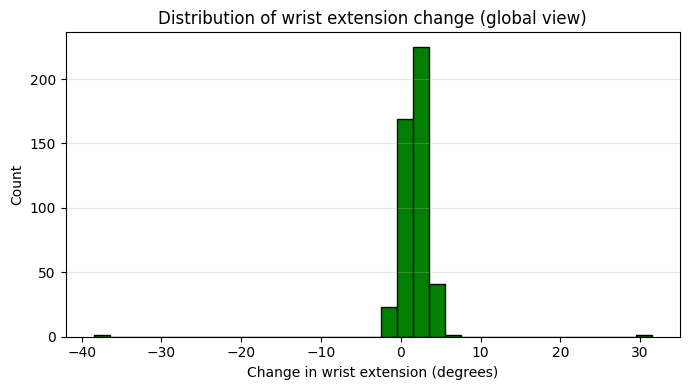

Histogram exported to:
results\figures_exploratory\hist_delta_wrist_extension_deg_global.png


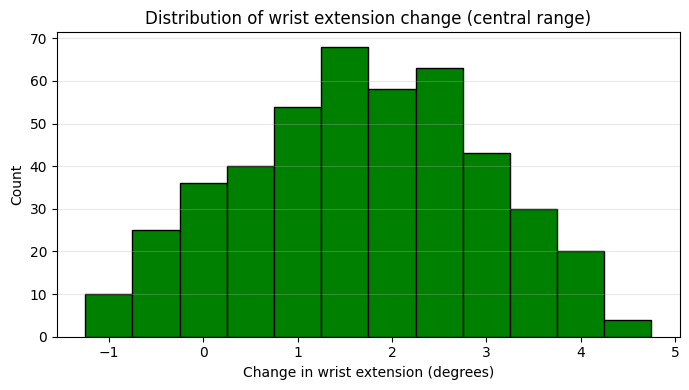

Histogram exported to:
results\figures_exploratory\hist_delta_wrist_extension_deg_central.png


In [147]:
# Define fixed-width bins for the global wrist extension histogram
wrist_global_bins = np.arange(
    np.floor(analysis_df["delta_wrist_extension_deg"].min()) - 0.5,
    np.ceil(analysis_df["delta_wrist_extension_deg"].max()) + 0.5,
    2
)

# Plot the global histogram for wrist extension change
plt.figure(figsize=(7, 4))
plt.hist(
    analysis_df["delta_wrist_extension_deg"].dropna(),
    bins=wrist_global_bins,
    color="green",
    edgecolor="black"
)
plt.xlabel("Change in wrist extension (degrees)")
plt.ylabel("Count")
plt.title("Distribution of wrist extension change (global view)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save the figure
wrist_global_file = figures_dir / "hist_delta_wrist_extension_deg_global.png"
plt.savefig(wrist_global_file, dpi=300, bbox_inches="tight")
plt.show()

print("Histogram exported to:")
print(wrist_global_file)

# Select the central part of the wrist extension change distribution
wrist_q01 = analysis_df["delta_wrist_extension_deg"].quantile(0.01)
wrist_q99 = analysis_df["delta_wrist_extension_deg"].quantile(0.99)

wrist_central = analysis_df["delta_wrist_extension_deg"].dropna()
wrist_central = wrist_central[(wrist_central >= wrist_q01) & (wrist_central <= wrist_q99)]

# Define fixed-width bins of 0.5 degree for the central histogram
wrist_central_bins = np.arange(
    np.floor(wrist_central.min()) - 0.25,
    np.ceil(wrist_central.max()) + 0.25,
    0.5
)

# Plot the central histogram for wrist extension change
plt.figure(figsize=(7, 4))
plt.hist(
    wrist_central,
    bins=wrist_central_bins,
    color="green",
    edgecolor="black"
)
plt.xlabel("Change in wrist extension (degrees)")
plt.ylabel("Count")
plt.title("Distribution of wrist extension change (central range)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save the figure
wrist_central_file = figures_dir / "hist_delta_wrist_extension_deg_central.png"
plt.savefig(wrist_central_file, dpi=300, bbox_inches="tight")
plt.show()

print("Histogram exported to:")
print(wrist_central_file)

### _Interpretation of the wrist extension histograms_

The global histogram shows that most wrist extension changes are concentrated in a narrow positive range, while a few extreme values extend the full distribution.

The central histogram provides a clearer view of the main distribution by focusing on the central range of the data.
It shows that most participants have __small positive changes in wrist extension, generally between approximately 0 and 3 degrees, with the highest concentration around 1 to 2.5 degrees__

A smaller number of participants show slight negative changes.
Overall, the graphical distribution is consistent with the descriptive summary table and suggests that wrist extension change is usually modest and more often positive than negative.

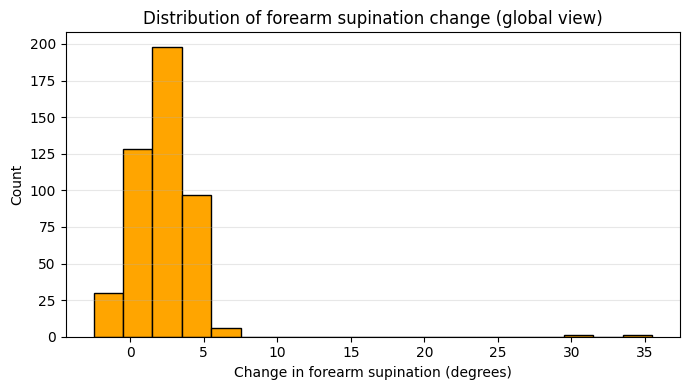

Histogram exported to:
results\figures_exploratory\hist_delta_forearm_supination_deg_global.png


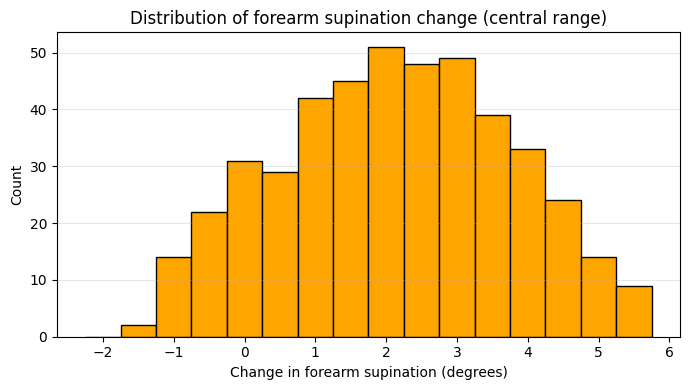

Histogram exported to:
results\figures_exploratory\hist_delta_forearm_supination_deg_central.png


In [148]:
# Define fixed-width bins for the global forearm supination histogram
sup_global_bins = np.arange(
    np.floor(analysis_df["delta_forearm_supination_deg"].min()) - 0.5,
    np.ceil(analysis_df["delta_forearm_supination_deg"].max()) + 0.5,
    2
)

# Plot the global histogram for forearm supination change
plt.figure(figsize=(7, 4))
plt.hist(
    analysis_df["delta_forearm_supination_deg"].dropna(),
    bins=sup_global_bins,
    color="orange",
    edgecolor="black"
)
plt.xlabel("Change in forearm supination (degrees)")
plt.ylabel("Count")
plt.title("Distribution of forearm supination change (global view)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save the figure
sup_global_file = figures_dir / "hist_delta_forearm_supination_deg_global.png"
plt.savefig(sup_global_file, dpi=300, bbox_inches="tight")
plt.show()

print("Histogram exported to:")
print(sup_global_file)

# Select the central part of the forearm supination change distribution
sup_q01 = analysis_df["delta_forearm_supination_deg"].quantile(0.01)
sup_q99 = analysis_df["delta_forearm_supination_deg"].quantile(0.99)

sup_central = analysis_df["delta_forearm_supination_deg"].dropna()
sup_central = sup_central[(sup_central >= sup_q01) & (sup_central <= sup_q99)]

# Define fixed-width bins of 0.5 degree for the central histogram
sup_central_bins = np.arange(
    np.floor(sup_central.min()) - 0.25,
    np.ceil(sup_central.max()) + 0.25,
    0.5
)

# Plot the central histogram for forearm supination change
plt.figure(figsize=(7, 4))
plt.hist(
    sup_central,
    bins=sup_central_bins,
    color="orange",
    edgecolor="black"
)
plt.xlabel("Change in forearm supination (degrees)")
plt.ylabel("Count")
plt.title("Distribution of forearm supination change (central range)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save the figure
sup_central_file = figures_dir / "hist_delta_forearm_supination_deg_central.png"
plt.savefig(sup_central_file, dpi=300, bbox_inches="tight")
plt.show()

print("Histogram exported to:")
print(sup_central_file)

### _Interpretation of the forearm supination histograms_

The global histogram shows that most forearm supination changes are concentrated in a positive range, while a few extreme values extend the full distribution.

The central histogram provides a clearer view of the main distribution by focusing on the central range of the data.
It shows that __most participants have small to moderate positive changes in forearm supination, generally between approximately 0 and 5 degrees, with the highest concentration around 1.5 to 3.5 degrees.__

A smaller number of participants show slight negative changes.
Overall, the graphical distribution is consistent with the descriptive summary table and suggests that forearm supination change is usually modest and more often positive than negative.

### _Summary of exploratory outputs_

The descriptive summary table and the histograms provide a consistent overview of the two primary outcome variables.

Together, these outputs show that most participants present small to moderate positive changes, while a limited number of extreme observations remain visible in the full distributions.

The final analysis dataset is now ready to be exported for the statistical analyses in RStudio.

## 6. Export the final analysis dataset

The final analysis dataset is exported after outcome computation and review of extreme values.

This file will be used in RStudio for:

- descriptive statistics
- paired statistical tests
- final tables and figures

In [149]:
# Define the output file for the final analysis dataset
analysis_output_file = processed_dir / "analysis_dataset.csv"

# Export the final analysis dataset
analysis_df.to_csv(analysis_output_file, index=False)

# Print a confirmation message
print("The final analysis dataset was successfully exported to:")
print(analysis_output_file)

The final analysis dataset was successfully exported to:
data\processed\analysis_dataset.csv
